<a href="https://colab.research.google.com/github/chimaobimarcellinus/basic_CNN/blob/main/CNN_for_handwritten_recog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Here is how the work flow is going to look like
      Dataset</br>
      load images</br>
      preprocess</br>
      Build Cnn </br>
      Train </br>
      Evaluate</br>
      Predict</br>

In [45]:
# importing important libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

the syntax `from tensorflow.keras import layers` </br>
A CNN is made of layers such as </br>
1. Conv2D
2. MaxPooling2D
3. Dense
4. Flatten
this import give us access to them

In [46]:
# loading the datasets into tain images and test images and teain labes and test labels

(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

In [47]:
print(train_images.shape)

(60000, 28, 28)


The image output here `(60000, 28, 28)` it means that they are 60000 images and each image has 28 rows and 28 columns

In [48]:
print(train_labels[:10])

[5 0 4 1 9 2 1 3 1 4]


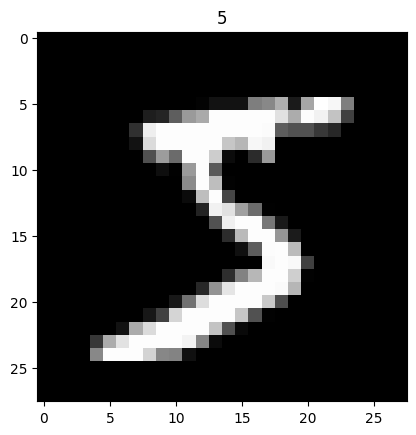

In [49]:
# display an image
plt.imshow(train_images[0], cmap='gray')
plt.title(train_labels[0])
plt.show()

In [50]:
# let us see the array of a the image
train_images[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

From the output image arrays, it is seen that we have zeros and integers so for training, it is better to convert the image to zeros and ones  (normalization: where the values are between 0 - 1). This can be done by dividing each element of array by **255**.
</br>
<br>
Digital images are made of pixels, and each color channel (Red, Green, Blue) is usually stored as an 8-bit integer.An 8-bit number holds 2⁸ = 256 possible values.These values range from 0 (completely dark/off) to 255 (completely bright/full intensity). <br>
therefore;<br>
`train_images = train_images/255` <br>

`test_images = test_images / 255`


In [51]:
train_images = train_images/255
test_images = test_images/255

Text(0.5, 1.0, '5')

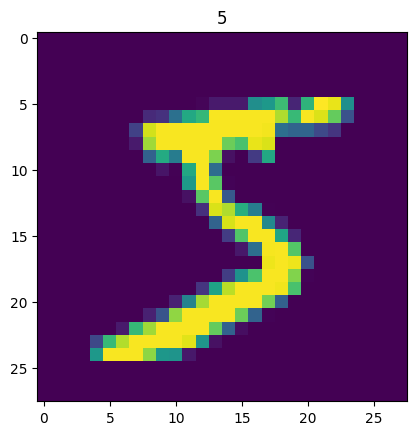

In [52]:
# notice that normalization did not remove the colour in the image
plt.imshow(train_images[0])
plt.title(train_labels[0])

In [53]:
# adding channel to the Dimension. CNN expects [height, width, channels]
# for gray scale Channel = 1
# for RGB Channel = 3
# so instead of (60000, 28, 28), we have (60000, 28, 28, 1)

train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

In [54]:
# build the CNN model
model = models.Sequential()

In [55]:
# first convolution layer
model.add(layers.Conv2D(
    filters = 32,
    kernel_size = (3,3),
    activation = "relu",
    input_shape = (28, 28, 1)
))

# Max Pooling
model.add(layers.MaxPooling2D((2,2)))

# second convolution layer
model.add(layers.Conv2D(64, (3,3), activation = "relu"))
# above  we increase the number of filters from 32 to 64. As the network goes deeper, it can learn more complex features
model.add(layers.MaxPooling2D((2,2)))

# flattens
model.add(layers.Flatten()) #after convolution and pooling, the data is still a multi-dimensional feature map
# this prepare the data for the fully connected layers

# Fully Connected Layer
model.add(layers.Dense(64, activation = "relu")) # A dense (fully connected) layer combines all extracted features
# to make a decision. the 64 neurons learn relationships among the features extracted by the convolutional layers


# Output Layer
# model.add(layers.Dense(10, activation = "softmax")) # there are 10 possible classes (digits 0 - 9), so we used 10 output neurins
# the softmax activation converts the output into probabilities that sum to 1.

# without activation in the output layer
model.add(layers.Dense(10))


In [56]:
# Compile the Model
model.compile(
    optimizer = "adam",
    # loss = "sparse_categorical_crossentropy",
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ["accuracy"]
)



*   Optimizer (adam); updates the model weights efficiently during training.
*   Loss(sparse_categorical_entropy) measures how wrong the predictions are for the integer labels
* Accuracy report the % of correct predictions



## Train the Model

In [57]:
history = model.fit(
    train_images,
    train_labels,
    epochs = 10,
    validation_split = 0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 33ms/step - accuracy: 0.9513 - loss: 0.1600 - val_accuracy: 0.9819 - val_loss: 0.0623
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 35ms/step - accuracy: 0.9847 - loss: 0.0498 - val_accuracy: 0.9834 - val_loss: 0.0551
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.9898 - loss: 0.0342 - val_accuracy: 0.9862 - val_loss: 0.0502
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 33ms/step - accuracy: 0.9915 - loss: 0.0258 - val_accuracy: 0.9879 - val_loss: 0.0430
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.9939 - loss: 0.0189 - val_accuracy: 0.9875 - val_loss: 0.0442
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.9950 - loss: 0.0155 - val_accuracy: 0.9862 - val_loss: 0.0450
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 33ms/step - accuracy: 0.9966 - loss: 0.0109 - val_accuracy: 0.9874 - val_loss: 0.0545
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.9963 -

## Evaluate the Model

In [58]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print ("Test Accuracy: ", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9896 - loss: 0.0401
Test Accuracy:  0.9896000027656555


## Make Predictions

In [59]:
predictions = model.predict(test_images)

import numpy as np

predicted_digit = np.argmax(predictions[0])

print("Predicted:", predicted_digit)
print("Actual: ", test_labels[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Predicted: 7
Actual:  7


## Saving the model

In [60]:
model.save("model.keras")

In [62]:
# how to load it later

from tensorflow.keras.models import load_model

# Reconstruct the exact same model perfectly
loaded_model = load_model("model.keras")